In [ ]:
# %load_ext gradio
pip install ipykernel

: 

In [ ]:
# !rm -rf .virtual_documents __notebook_source__.ipynb .config sample_data .git saved_models taming-transformers
# !git lfs install
# !git clone https://github.com/ErwannMillon/face-editor.git .

: 

In [ ]:
# !git clone https://github.com/openai/CLIP.git
# !git clone https://github.com/CompVis/taming-transformers.git taming
# # !mv taming taming
import os
import sys
sys.path.append("taming-transformers")

: 

In [4]:
# !git submodule init

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')
# !cp /content/drive/MyDrive/vqgan/vqgan_only.pt ./vqgan_only.pt

In [6]:
# !pip install gradio
# !pip install -r requirements.txt
# # !pip install ftfy regex tqdm omegaconf pytorch-lightning IPython kornia imageio imageio-ffmpeg einops torch_optimizer setuptools==59.5.0 importlib transformers
# !pip install ftfy regex tqdm omegaconf pytorch-lightning IPython einops torch_optimizer setuptools==59.5.0 importlib transformers

In [7]:
import torch
import gradio as gr
import importlib
import loaders
import functools
import edit
import importlib
from loaders import load_default
device = "cpu"
vqgan = load_default(device)
vqgan.eval()

/opt/homebrew/Caskroom/miniforge/base/envs/taming/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/homebrew/Caskroom/miniforge/base/envs/taming/lib/python3.8/site-packages/pytorch_lightning/utilities/distributed.py:258: LightningDeprecationWarning: `pytorch_lightning.utilities.distributed.rank_zero_only` has been deprecated in v1.8.1 and will be removed in v1.10.0. You can import it from `pytorch_lightning.utilities` instead.
  rank_zero_deprecation(


Working with z of shape (1, 256, 16, 16) = 65536 dimensions.


VQModel(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down): ModuleList(
      (0): Module(
        (block): ModuleList(
          (0): ResnetBlock(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (1): ResnetBlock(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
        )
        

In [8]:
# !git pull

In [9]:
import torchvision
from transformers import CLIPProcessor, CLIPModel
class ProcessorGradientFlow():
    def __init__(self, device="cuda") -> None:
        self.device = device
        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        self.image_mean = [0.48145466, 0.4578275, 0.40821073]
        self.image_std = [0.26862954, 0.26130258, 0.27577711]
        self.normalize = torchvision.transforms.Normalize(
            self.image_mean,
            self.image_std
        )
        self.resize = torchvision.transforms.Resize(224)
        self.center_crop = torchvision.transforms.CenterCrop(224)
    def preprocess_img(self, images):
        images = self.center_crop(images)
        images = self.resize(images)
        images = self.center_crop(images)
        images = self.normalize(images)
        return images
    def __call__(self, images=[], **kwargs):
        processed_inputs = self.processor(**kwargs)
        processed_inputs["pixel_values"] = self.preprocess_img(images)
        processed_inputs = {key:value.to(self.device) for (key, value) in processed_inputs.items()}
        return processed_inputs

In [10]:
processor = ProcessorGradientFlow()
clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip.to(device)

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0): CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05, element

In [11]:
import torch.nn as nn
from img_processing import *
from utils import freeze_module
import matplotlib.pyplot as plt
from tqdm import tqdm
class ImagePromptOptimizer(nn.Module):
    def __init__(self, 
                vqgan, 
                clip,
                clip_preprocessor,
                iterations=100,
                lr = 0.01,
                save_vector=True,
                return_val="latent",
                quantize=True,
                make_grid=False) -> None:
                
        super().__init__()
        self.latent = None
        self.device = vqgan.device
        vqgan.eval()
        self.vqgan = vqgan
        self.clip = clip
        self.iterations = iterations
        self.lr = lr
        self.clip_preprocessor = clip_preprocessor
        self.make_grid = make_grid
        self.return_val = return_val
        self.quantize = quantize
    def set_latent(self, latent):
        self.latent = latent.detach().to(self.device)
    def set_params(self, lr, iterations, attn_mask):
        self.attn_mask = attn_mask
        self.iterations = iterations
        self.lr = lr
    def forward(self, vector):
        base_latent = self.latent.detach().requires_grad_()
        trans_latent = base_latent + vector
        if self.quantize:
          z_q, *_ = self.vqgan.quantize(trans_latent)
        else:
          z_q = trans_latent
        dec = self.vqgan.decode(z_q)
        return dec
    def _get_clip_similarity(self, prompts, image, weights=None):
        if isinstance(prompts, str):
            prompts = [prompts]
        elif not isinstance(prompts, list):
            raise TypeError("Provide prompts as string or list of strings")
        clip_inputs = self.clip_preprocessor(text=prompts,
            images=image, return_tensors="pt", padding=True)
        clip_outputs = self.clip(**clip_inputs)
        similarity_logits = clip_outputs.logits_per_image
        if weights:
            similarity_logits *= weights
        return similarity_logits.sum()
    def get_similarity_loss(self, pos_prompts, neg_prompts, image):
        pos_logits = self._get_clip_similarity(pos_prompts, image)
        if neg_prompts:
            neg_logits = self._get_clip_similarity(neg_prompts, image)
        else:
            neg_logits = torch.tensor([0], device=self.device)
        loss = -torch.log(pos_logits) + torch.log(neg_logits)
        return loss
    def visualize(self, processed_img):
        if self.make_grid:
            self.index += 1
            plt.subplot(1, 9, self.index)
            plt.imshow(get_pil(processed_img[0]).detach().cpu())
        else:
            plt.imshow(get_pil(processed_img[0]).detach().cpu())
            plt.show()
    def optimize(self, latent, pos_prompts, neg_prompts):
        self.set_latent(latent)
        vector = torch.randn_like(self.latent, requires_grad=True, device=self.device)
        optim = torch.optim.Adam([vector], lr=self.lr)
        if self.make_grid:
            plt.figure(figsize=(35, 25))
            self.index = 1
        for i in tqdm(range(self.iterations)):
            transformed_img = self(vector)
            processed_img = loop_post_process(transformed_img)
            # p1 = processed_img.retain_grad().grad
            # print(p1)
            loss = self.get_similarity_loss(pos_prompts, neg_prompts, processed_img)
            optim.zero_grad()
            # p2 = processed_img.grad
            # print(p2)
            loss.backward()
            # p3 = processed_img.retain_grad().grad
            # print(p3, p3.shape)
            optim.step()
            return
            # if i % self.iterations // 10 == 0: 
                # self.visualize(processed_img)
            yield vector
        # if self.make_grid:
            # plt.savefig(f"plot {pos_prompts[0]}.png")
            # plt.show()
        # yield vector if self.return_val == "vector" else self.latent + vector

In [12]:
clip.device

device(type='cpu')

In [13]:
from img_processing import custom_to_pil
import edit
importlib.reload(edit)
from edit import blend_paths
class ImageState:
    def __init__(self, vqgan, prompt_optimizer: ImagePromptOptimizer) -> None:
        self.vqgan = vqgan
        self.device = vqgan.device
        #latentvectors
        self.lip_vector = torch.load("./latent_vectors/lipvector.pt", map_location=self.device)
        self.red_blue_vector = torch.load("./latent_vectors/red_blue.pt", map_location=self.device)
        self.green_purple_vector = torch.load("./latent_vectors/green_purple.pt", map_location=self.device)
        # self.gender_vector = torch.load("./latent_vectors/gender.pt")
        self.asian_vector = torch.load("./latent_vectors/asian10.pt", map_location=self.device)
        #latent transforms
        self.hair_rb = torch.zeros_like(self.lip_vector)
        self.lip_transforms = torch.zeros_like(self.lip_vector)
        self.gender_transforms = torch.zeros_like(self.lip_vector)
        self.prompt_transforms = torch.zeros_like(self.lip_vector) 
        self.hair_gp = torch.zeros_like(self.lip_vector)
        self.blend_latent = None
        self.quant = True
        self.prompt_optim = prompt_optimizer
    def _apply_vector(self, src, vector):
        new_latent = torch.lerp(src, src + vector, 1)
        return new_latent
    def _decode_latent(self, latent):
        current_im = self.vqgan.decode(latent.to(self.device))[0]
        return custom_to_pil(current_im)
    def _render_all_transformations(self):
        self.current_vector_transforms = [self.hair_rb, self.lip_transforms, self.hair_gp, self.gender_transforms, self.prompt_transforms]
        new_latent = self.blend_latent + sum(self.current_vector_transforms).to(self.device)
        if self.quant:
            new_latent, _, _ = self.vqgan.quantize(new_latent.to(self.device))
        return self._decode_latent(new_latent)
    def apply_gp_vector(self, weight):
        self.hair_gp = weight * self.green_purple_vector
        return self._render_all_transformations()
    def apply_rb_vector(self, weight):
        self.hair_rb = weight * self.red_blue_vector
        return self._render_all_transformations()
    def apply_lip_vector(self, weight):
        self.lip_transforms = weight * self.lip_vector
        return self._render_all_transformations()
    def update_requant(self, val):
        print(f"val = {val}")
        self.quant = val
        return self._render_all_transformations()
    def apply_gender_vector(self, weight):
        self.gender_transforms = weight * self.asian_vector
        return self._render_all_transformations()
    def blend(self, path1, path2, weight):
        img, latent = blend_paths(self.vqgan, path1, path2, weight=weight, show=False, device=self.device)
        self.blend_latent = latent.to(self.device)
        return self._render_all_transformations()
    def apply_prompts(self, positive_prompts, negative_prompts, lr, iterations, img):
        attn_mask = img["mask"]
        print(type(attn_mask))
        print(attn_mask.shape)
        self.prompt_optim.set_params(lr, iterations, attn_mask)
        for i, transform in enumerate(self.prompt_optim.optimize(self.blend_latent,
                                                positive_prompts,
                                                negative_prompts)):
          
          print(i)
          self.prompt_transforms = transform
          yield self._render_all_transformations()
        # transform = self.prompt_optim.optimize(self.blend_latent,
                                                # positive_prompts,
                                                # negative_prompts)
        # self.prompt_transforms = transform
        # return self._render_all_transformations()

/opt/homebrew/Caskroom/miniforge/base/envs/taming/lib/python3.8/site-packages/torchvision/transforms/functional.py:442: UserWarning: Argument 'interpolation' of type int is deprecated since 0.13 and will be removed in 0.15. Please use InterpolationMode enum.
  warnings.warn(


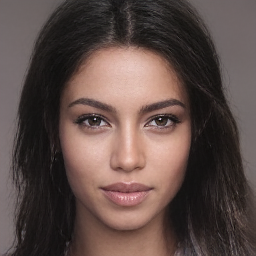

In [14]:
promptoptim = ImagePromptOptimizer(vqgan, clip, processor, quantize=False)
test = ImageState(vqgan, promptoptim)
test.blend("./test_data/face.jpeg", "./test_data/face2.jpeg", 0.5)
test.apply_lip_vector(0.6)

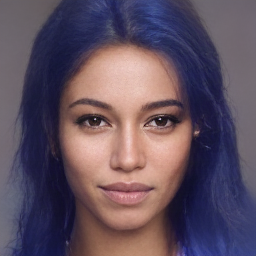

In [15]:
test.apply_rb_vector(.8)

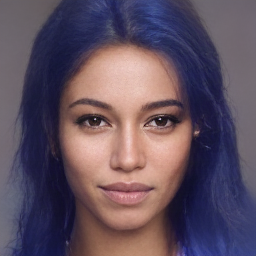

In [16]:
test.apply_lip_vector(.6)

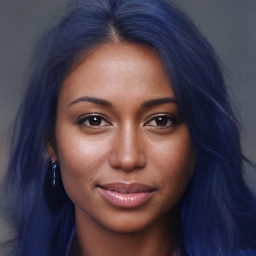

In [17]:
test.blend("./test_data/face.jpeg", "./test_data/face2.jpeg", 0.1)

In [18]:
# !git pull

In [19]:
# %load_ext gradio

In [20]:
# %%blocks
import functools
import edit
import importlib
importlib.reload(edit)
# bp = functools.partial(edit.blend_paths, model, show=False)
model = vqgan
promptoptim = ImagePromptOptimizer(model, clip, processor, quantize=False)
state = ImageState(model, promptoptim)
with gr.Blocks() as demo:
    with gr.Row():
        with gr.Column(scale=2):
            hair_red_blue = gr.Slider(
                label="hair red<->blue ",
                minimum=-.8,
                maximum=.8,
                value=0,
                step=0.1,
            )
            hair_green_purple = gr.Slider(
                label="hair green<->purple ",
                minimum=-.8,
                maximum=.8,
                value=0,
                step=0.1,
            )
            lip_size = gr.Slider(
                label="lip size",
                minimum=-1.9,
                value=0,
                maximum=1.9,
                step=0.1,
            )
            blend_weight = gr.Slider(
                label="0 is src image, 1 is blend_img",
                minimum=-0.,
                value=0,
                maximum=1.,
                step=0.1,
            )
            requantize = gr.Checkbox(
                label="requantize latents",
                value=True,
            )
            gender_weight = gr.Slider(
                label="gender weight (-1 female, 1 male)",
                minimum=-2.,
                value=0,
                maximum=2.,
                step=0.07,
            )
            with gr.Row():
                with gr.Column(scale=1):
                    base_img = gr.Image(label="base Image", type="filepath")
                    blend_img = gr.Image(label="image for face blending (optional)", type="filepath")
                with gr.Column(scale=2):
                    positive_prompts = gr.Textbox(label="Positive prompts")
                    negative_prompts = gr.Textbox(label="Negative prompts")
                    iterations = gr.Slider(minimum=10,
                                            maximum=300,
                                            value=40,
                                            label="optimization iterations",)
                    learning_rate = gr.Slider(minimum=1e-3,
                                            maximum=1e-1,
                                            value=1e-2,
                                            label="learning rate")
                    apply_prompts = gr.Button(value="Apply Prompts")

        with gr.Column(scale=1):
            out = gr.Image(interactive=True, tool="sketch", shape=(200, 200))
            test = gr.Image(interactive=False, shape=(200, 200))
            i = gr.Button()
    gender_weight.change(state.apply_gender_vector, inputs=[gender_weight], outputs=out)
    requantize.change(state.update_requant, inputs=[requantize], outputs=out)
    lip_size.change(state.apply_lip_vector, inputs=[lip_size], outputs=out)
    hair_green_purple.change(state.apply_gp_vector, inputs=[hair_green_purple], outputs=out)
    hair_red_blue.change(state.apply_rb_vector, inputs=[hair_red_blue], outputs=out)
    blend_weight.change(state.blend, inputs=[base_img, blend_img, blend_weight], outputs=out)
    base_img.change(state.blend, inputs=[base_img, base_img, blend_weight], outputs=out)
    blend_img.change(state.blend, inputs=[base_img, blend_img, blend_weight], outputs=out)
    apply_prompts.click(state.apply_prompts, inputs=[positive_prompts, negative_prompts, learning_rate, iterations, out], outputs=out)
demo.queue()
demo.launch(debug=True, inbrowser=True)

Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


In [ ]:
%tb